In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import RMSprop


# **Environment Setup**

In [2]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [3]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [4]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [5]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [6]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [7]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [8]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [9]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [10]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [11]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


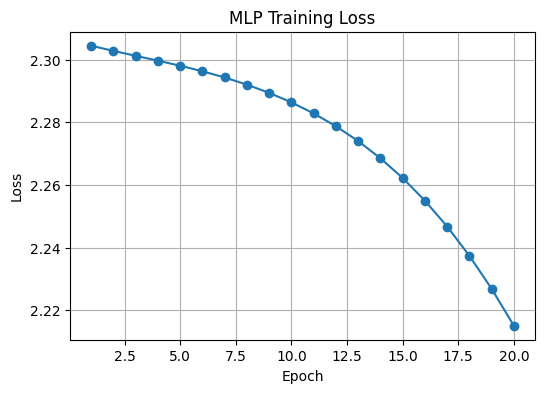

In [12]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [13]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [14]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [15]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [16]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703253986288
Maximum difference for W2: 0.030647578993040124


# PART 2

In [17]:
np.random.seed(42)
tf.random.set_seed(42)

#encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [18]:
X_grad_sample = X_val[0:128]
y_grad_sample = y_val_cat[0:128]

In [19]:
#this will get the gradient i get the issue and get to know
#fit() doesnt give me graident so this will get it
class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_sample, y_sample):
        super().__init__()
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.grad_history = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.X_sample, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(self.y_sample, preds))

        first_layer_w = self.model.layers[0].trainable_weights[0]
        grad = tape.gradient(loss, [first_layer_w])[0]
        self.grad_history.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [20]:
#Sigmoid
sigmoid_model = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

sigmoid_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

sigmoid_logger = GradientLogger(X_grad_sample, y_grad_sample)

sigmoid_history = sigmoid_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=5, batch_size=128,
                                     callbacks=[sigmoid_logger],
                                     verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1789279534.887807      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789279534.890738      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/5
 71/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3998 - loss: 2.0572

I0000 00:00:1789279538.645726     155 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7254 - loss: 0.9485 - val_accuracy: 0.8140 - val_loss: 0.5487
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8315 - loss: 0.4872 - val_accuracy: 0.8397 - val_loss: 0.4471
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8503 - loss: 0.4219 - val_accuracy: 0.8501 - val_loss: 0.4124
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8624 - loss: 0.3887 - val_accuracy: 0.8578 - val_loss: 0.3923
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8696 - loss: 0.3662 - val_accuracy: 0.8633 - val_loss: 0.3777


In [21]:
#TANH
tanh_model = Sequential([
    Dense(128, input_dim=784, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])

tanh_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

tanh_logger = GradientLogger(X_grad_sample, y_grad_sample)

tanh_history = tanh_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[tanh_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8081 - loss: 0.5531 - val_accuracy: 0.8271 - val_loss: 0.4638
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3925 - val_accuracy: 0.8403 - val_loss: 0.4206
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8715 - loss: 0.3560 - val_accuracy: 0.8482 - val_loss: 0.4026
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.3310 - val_accuracy: 0.8527 - val_loss: 0.3915
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8876 - loss: 0.3110 - val_accuracy: 0.8562 - val_loss: 0.3818


In [22]:
#RELU 
relu_model = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

relu_logger = GradientLogger(X_grad_sample, y_grad_sample)

relu_history = relu_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[relu_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7947 - loss: 0.5992 - val_accuracy: 0.8146 - val_loss: 0.5040
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8526 - loss: 0.4118 - val_accuracy: 0.8280 - val_loss: 0.4564
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8685 - loss: 0.3684 - val_accuracy: 0.8497 - val_loss: 0.4050
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8793 - loss: 0.3394 - val_accuracy: 0.8534 - val_loss: 0.3901
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8857 - loss: 0.3184 - val_accuracy: 0.8577 - val_loss: 0.3777


In [23]:
#LEAKY RELU 
leaky_model = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

leaky_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

leaky_logger = GradientLogger(X_grad_sample, y_grad_sample)

leaky_history = leaky_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=5, batch_size=128,
                                 callbacks=[leaky_logger],
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8041 - loss: 0.5762 - val_accuracy: 0.8373 - val_loss: 0.4459
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8549 - loss: 0.4076 - val_accuracy: 0.8307 - val_loss: 0.4409
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8684 - loss: 0.3681 - val_accuracy: 0.8362 - val_loss: 0.4282
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.3417 - val_accuracy: 0.8413 - val_loss: 0.4142
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8834 - loss: 0.3210 - val_accuracy: 0.8447 - val_loss: 0.4076


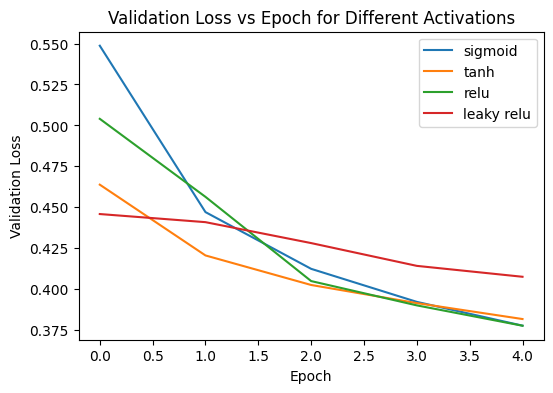

In [24]:
# plotting all 4 val loss curves together
plt.figure(figsize=(6,4))
plt.plot(sigmoid_history.history['val_loss'], label='sigmoid')
plt.plot(tanh_history.history['val_loss'], label='tanh')
plt.plot(relu_history.history['val_loss'], label='relu')
plt.plot(leaky_history.history['val_loss'], label='leaky relu')

plt.title("Validation Loss vs Epoch for Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [25]:
#epoch 1 and last
print("sigmoid grad epoch 1:", sigmoid_logger.grad_history[0])
print("sigmoid grad last epoch:", sigmoid_logger.grad_history[-1])

print("relu grad epoch 1:", relu_logger.grad_history[0])
print("relu grad last epoch:", relu_logger.grad_history[-1])

sigmoid grad epoch 1: 0.00025418945
sigmoid grad last epoch: 0.00044821584
relu grad epoch 1: 0.0021520876
relu grad last epoch: 0.0019211334


so by this we can see that for the sigmoid the learning is very less as compared to the relu as there is difference in both values for sigmoid and relu

so in short words the relu provides a better learning as compared to the sigmoid


In [26]:
#if output is 0 it is dead relu
W1_relu, b1_relu = relu_model.layers[0].get_weights()

Z1 = np.dot(X_val[:256], W1_relu) + b1_relu
A1 = relu(Z1)   #relu from p1

dead_units = np.all(A1 == 0, axis=0) #check all
dead_percentage = np.mean(dead_units) * 100
print("percentage of dead relu units:", dead_percentage, "%")

percentage of dead relu units: 4.6875 %


3.9% are 0 this is very small ratio and i think it is not that concerning but to name it this is the dying relu problem for which solution exists but here the number is small so we will ignore it the solution to solve the dying relu problem is >* Leaky Relu (0.01x,x)*

# PART 3

here i am using sample data set of diabetes which i explored on
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [27]:
#CROSS ENTROPY MODEL
#using the same relu architecture from part 2 (128, 64)
ce_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ce_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ce_history = ce_model.fit(X_train, y_train_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=5, batch_size=128,
                           verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8120 - loss: 0.5307 - val_accuracy: 0.8584 - val_loss: 0.3995
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8630 - loss: 0.3815 - val_accuracy: 0.8669 - val_loss: 0.3594
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.3393 - val_accuracy: 0.8577 - val_loss: 0.3776
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8871 - loss: 0.3116 - val_accuracy: 0.8572 - val_loss: 0.3856
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8940 - loss: 0.2914 - val_accuracy: 0.8524 - val_loss: 0.3936


In [28]:
y_test_cat = to_categorical(y_test, 10)

ce_test_loss, ce_test_acc = ce_model.evaluate(X_test, y_test_cat, verbose=0)
print("cross entropy test accuracy:", ce_test_acc)

cross entropy test accuracy: 0.8539999723434448


In [29]:
#MSE MODEL 
#same as above only loss function differ
mse_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mse_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

mse_history = mse_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=5, batch_size=128,
                             verbose=1)

mse_test_loss, mse_test_acc = mse_model.evaluate(X_test, y_test_cat, verbose=0)
print("mse test accuracy:", mse_test_acc)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8112 - loss: 0.0273 - val_accuracy: 0.8388 - val_loss: 0.0231
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8604 - loss: 0.0204 - val_accuracy: 0.8273 - val_loss: 0.0247
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8752 - loss: 0.0185 - val_accuracy: 0.8302 - val_loss: 0.0242
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8840 - loss: 0.0172 - val_accuracy: 0.8538 - val_loss: 0.0213
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8903 - loss: 0.0164 - val_accuracy: 0.8710 - val_loss: 0.0187
mse test accuracy: 0.8723999857902527


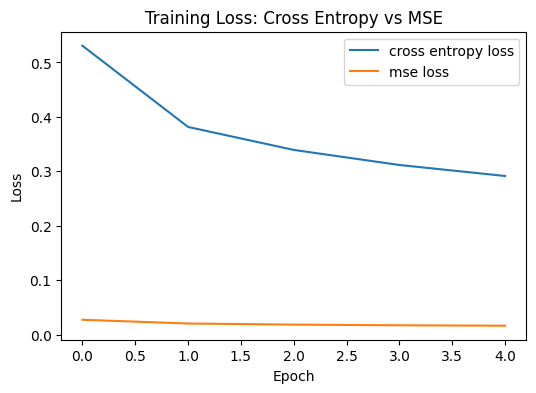

In [30]:
plt.figure(figsize=(6,4))
plt.plot(ce_history.history['loss'], label='cross entropy loss')
plt.plot(mse_history.history['loss'], label='mse loss')
plt.title("Training Loss: Cross Entropy vs MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Diabetes DataSet**

In [31]:
diabetes = load_diabetes()
X_diab = diabetes.data
y_diab = diabetes.target

print("X shape:", X_diab.shape)
print("y sample:", y_diab[0:5])

X shape: (442, 10)
y sample: [151.  75. 141. 206. 135.]


In [32]:
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_diab_train = scaler.fit_transform(X_diab_train)
X_diab_test = scaler.transform(X_diab_test)

In [33]:
reg_model = Sequential([
    Dense(40, input_dim=X_diab_train.shape[1], activation='relu'),
    Dense(20, activation='relu'),
    Dense(1)  #no activation function as this is regression
])

reg_model.compile(optimizer=Adam(learning_rate=0.01),
                   loss='mse',
                   metrics=['mae'])

reg_history = reg_model.fit(X_diab_train, y_diab_train,
                             validation_split=0.2,
                             epochs=50, batch_size=20,
                             verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 30029.0469 - mae: 154.3127 - val_loss: 19338.0781 - val_mae: 122.9724
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22169.9785 - mae: 129.0782 - val_loss: 10925.3877 - val_mae: 86.3932
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10198.6836 - mae: 78.1718 - val_loss: 4916.8755 - val_mae: 53.7926
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6492.3008 - mae: 62.5996 - val_loss: 3851.2554 - val_mae: 48.3479
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4522.4727 - mae: 53.4632 - val_loss: 3481.4727 - val_mae: 43.4610
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3865.4167 - mae: 49.2208 - val_loss: 3063.3882 - val_mae: 40.8671
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3463.1519 - mae: 46.5236 - val_loss: 2876.9763 - val_mae: 40.5440
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3258.4045 - mae: 45.5268 - val_loss: 2800.2925 - val_mae: 40.8370
Epoch 9/50

In [34]:
y_diab_pred = reg_model.predict(X_diab_test)

mse_val = mean_squared_error(y_diab_test, y_diab_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_diab_test, y_diab_pred)

print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("MAE:", mae_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
MSE: 2649.7856591043515
RMSE: 51.476068800019604
MAE: 41.364649226156516


When the MSE is combined with softmax it produces small gradients so by this the learning becomes slow but on the other hand corss-entropy with softmax the output is large as compared to MSE so it pushes the weights towards the correct answer

# PART 4

In [35]:
#Optimsers
def epochs_to_reach(history, target=0.85):
    val_acc = history.history['val_accuracy']

    epoch = 1

    for acc in val_acc:
        if acc >= target:
            return epoch
        epoch += 1

    return None
#loop for tracking epochs catch when accuracy gets 85

In [36]:
#SGD plain
sgd_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_model.compile(optimizer=SGD(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
sgd_history = sgd_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
sgd_time = time.time() - start

print("sgd epochs to 85%:", epochs_to_reach(sgd_history))
print("sgd final val acc:", sgd_history.history['val_accuracy'][-1])
print("sgd wall clock time:", sgd_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6995 - loss: 0.9732 - val_accuracy: 0.7688 - val_loss: 0.6892
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8025 - loss: 0.6063 - val_accuracy: 0.7955 - val_loss: 0.5830
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8201 - loss: 0.5339 - val_accuracy: 0.8038 - val_loss: 0.5428
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8293 - loss: 0.4977 - val_accuracy: 0.8098 - val_loss: 0.5225
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8358 - loss: 0.4746 - val_accuracy: 0.8115 - val_loss: 0.5094
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8411 - loss: 0.4576 - val_accuracy: 0.8142 - val_loss: 0.4988
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8446 - loss: 0.4443 - val_accuracy: 0.8157 - val_loss: 0.4909
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8484 - loss: 0.4333 - val_accuracy: 0.

In [37]:
#SGD with momentum

sgd_mom_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start = time.time()
sgd_mom_history = sgd_mom_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=20, batch_size=100,
                                     verbose=1)
sgd_mom_time = time.time() - start

print("sgd+momentum epochs to 85%:", epochs_to_reach(sgd_mom_history))
print("sgd+momentum final val acc:", sgd_mom_history.history['val_accuracy'][-1])
print("sgd+momentum wall clock time:", sgd_mom_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7839 - loss: 0.6232 - val_accuracy: 0.8372 - val_loss: 0.4587
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8476 - loss: 0.4289 - val_accuracy: 0.8514 - val_loss: 0.4080
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.3828 - val_accuracy: 0.8603 - val_loss: 0.3776
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8738 - loss: 0.3534 - val_accuracy: 0.8660 - val_loss: 0.3625
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8804 - loss: 0.3312 - val_accuracy: 0.8708 - val_loss: 0.3537
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8867 - loss: 0.3132 - val_accuracy: 0.8710 - val_loss: 0.3510
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8925 - loss: 0.2971 - val_accuracy: 0.8693 - val_loss: 0.3517
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8974 - loss: 0.2835 - val_accuracy: 0.

In [38]:
#RMSProp
rms_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_model.compile(optimizer=RMSprop(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
rms_history = rms_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
rms_time = time.time() - start

print("rmsprop epochs to 85%:", epochs_to_reach(rms_history))
print("rmsprop final val acc:", rms_history.history['val_accuracy'][-1])
print("rmsprop wall clock time:", rms_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7472 - loss: 1.0165 - val_accuracy: 0.7930 - val_loss: 0.5970
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8298 - loss: 0.4832 - val_accuracy: 0.7913 - val_loss: 0.5520
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8441 - loss: 0.4430 - val_accuracy: 0.8374 - val_loss: 0.4414
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8515 - loss: 0.4226 - val_accuracy: 0.8430 - val_loss: 0.4354
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.4142 - val_accuracy: 0.8259 - val_loss: 0.5535
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.4041 - val_accuracy: 0.8487 - val_loss: 0.4443
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8623 - loss: 0.3951 - val_accuracy: 0.8419 - val_loss: 0.4699
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.3925 - val_accuracy: 0.

In [39]:
#Adam
adam_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start = time.time()
adam_history = adam_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=100,
                               verbose=1)
adam_time = time.time() - start

print("adam epochs to 85%:", epochs_to_reach(adam_history))
print("adam final val acc:", adam_history.history['val_accuracy'][-1])
print("adam wall clock time:", adam_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7942 - loss: 0.6044 - val_accuracy: 0.7968 - val_loss: 0.5239
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8521 - loss: 0.4064 - val_accuracy: 0.8621 - val_loss: 0.3809
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.3751 - val_accuracy: 0.8601 - val_loss: 0.3702
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8714 - loss: 0.3546 - val_accuracy: 0.8642 - val_loss: 0.3683
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8734 - loss: 0.3479 - val_accuracy: 0.8547 - val_loss: 0.3975
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8790 - loss: 0.3332 - val_accuracy: 0.8468 - val_loss: 0.4162
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8834 - loss: 0.3218 - val_accuracy: 0.8639 - val_loss: 0.3969
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.3145 - val_accuracy: 0.

In [40]:
#TUNED LEARNING RATE PER OPTIMISER

In [41]:
# SGD tuned
sgd_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_tuned_model.compile(optimizer=SGD(learning_rate=0.1),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
sgd_tuned_history = sgd_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
sgd_tuned_time = time.time() - start

print("sgd tuned epochs to 85%:", epochs_to_reach(sgd_tuned_history))
print("sgd tuned final val acc:", sgd_tuned_history.history['val_accuracy'][-1])
print("sgd tuned wall clock time:", sgd_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7737 - loss: 0.6440 - val_accuracy: 0.7654 - val_loss: 0.5730
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8423 - loss: 0.4417 - val_accuracy: 0.8018 - val_loss: 0.4953
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8585 - loss: 0.3913 - val_accuracy: 0.8269 - val_loss: 0.4457
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8692 - loss: 0.3603 - val_accuracy: 0.8388 - val_loss: 0.4219
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.3369 - val_accuracy: 0.8483 - val_loss: 0.3938
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8840 - loss: 0.3181 - val_accuracy: 0.8568 - val_loss: 0.3788
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8894 - loss: 0.3021 - val_accuracy: 0.8622 - val_loss: 0.3615
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8946 - loss: 0.2884 - val_accuracy: 0.

In [42]:
#SGD + momentum tuned
sgd_mom_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_tuned_model.compile(optimizer=SGD(learning_rate=0.05, momentum=0.9),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

start = time.time()
sgd_mom_tuned_history = sgd_mom_tuned_model.fit(X_train, y_train_cat,
                                                 validation_data=(X_val, y_val_cat),
                                                 epochs=20, batch_size=100,
                                                 verbose=1)
sgd_mom_tuned_time = time.time() - start

print("sgd+momentum tuned epochs to 85%:", epochs_to_reach(sgd_mom_tuned_history))
print("sgd+momentum tuned final val acc:", sgd_mom_tuned_history.history['val_accuracy'][-1])
print("sgd+momentum tuned wall clock time:", sgd_mom_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7959 - loss: 0.5609 - val_accuracy: 0.8441 - val_loss: 0.4303
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8519 - loss: 0.4006 - val_accuracy: 0.8548 - val_loss: 0.3882
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3585 - val_accuracy: 0.8682 - val_loss: 0.3554
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8783 - loss: 0.3296 - val_accuracy: 0.8687 - val_loss: 0.3536
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8848 - loss: 0.3090 - val_accuracy: 0.8776 - val_loss: 0.3327
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8917 - loss: 0.2922 - val_accuracy: 0.8745 - val_loss: 0.3396
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8952 - loss: 0.2804 - val_accuracy: 0.8717 - val_loss: 0.3529
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.2674 - val_accuracy: 0.

In [43]:
#RMSProp tuned
rms_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_tuned_model.compile(optimizer=RMSprop(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
rms_tuned_history = rms_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
rms_tuned_time = time.time() - start

print("rmsprop tuned epochs to 85%:", epochs_to_reach(rms_tuned_history))
print("rmsprop tuned final val acc:", rms_tuned_history.history['val_accuracy'][-1])
print("rmsprop tuned wall clock time:", rms_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7883 - loss: 0.5849 - val_accuracy: 0.8041 - val_loss: 0.4960
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8530 - loss: 0.3988 - val_accuracy: 0.8438 - val_loss: 0.4120
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8691 - loss: 0.3501 - val_accuracy: 0.8537 - val_loss: 0.3762
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.3197 - val_accuracy: 0.8622 - val_loss: 0.3689
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8888 - loss: 0.2962 - val_accuracy: 0.8666 - val_loss: 0.3597
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 - loss: 0.2785 - val_accuracy: 0.8716 - val_loss: 0.3546
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9014 - loss: 0.2633 - val_accuracy: 0.8733 - val_loss: 0.3535
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9069 - loss: 0.2503 - val_accuracy: 0.

In [44]:
#Adam tuned
adam_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_tuned_model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

start = time.time()
adam_tuned_history = adam_tuned_model.fit(X_train, y_train_cat,
                                           validation_data=(X_val, y_val_cat),
                                           epochs=20, batch_size=100,
                                           verbose=1)
adam_tuned_time = time.time() - start

print("adam tuned epochs to 85%:", epochs_to_reach(adam_tuned_history))
print("adam tuned final val acc:", adam_tuned_history.history['val_accuracy'][-1])
print("adam tuned wall clock time:", adam_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8151 - loss: 0.5241 - val_accuracy: 0.8589 - val_loss: 0.4014
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.3786 - val_accuracy: 0.8654 - val_loss: 0.3646
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8791 - loss: 0.3331 - val_accuracy: 0.8706 - val_loss: 0.3500
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8883 - loss: 0.3065 - val_accuracy: 0.8695 - val_loss: 0.3518
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8955 - loss: 0.2872 - val_accuracy: 0.8648 - val_loss: 0.3634
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.2677 - val_accuracy: 0.8665 - val_loss: 0.3600
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9055 - loss: 0.2563 - val_accuracy: 0.8736 - val_loss: 0.3481
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.2446 - val_accuracy: 0.

In [45]:
#table for compare
results_table = pd.DataFrame({
    "Optimiser": ["SGD", "SGD+Momentum", "RMSProp", "Adam"],
    "Learning rate": [0.1, 0.05, 0.001, 0.001],
    "Epochs to 85% val acc": [
        epochs_to_reach(sgd_tuned_history),
        epochs_to_reach(sgd_mom_tuned_history),
        epochs_to_reach(rms_tuned_history),
        epochs_to_reach(adam_tuned_history)
    ],
    "Final val accuracy": [
        sgd_tuned_history.history['val_accuracy'][-1],
        sgd_mom_tuned_history.history['val_accuracy'][-1],
        rms_tuned_history.history['val_accuracy'][-1],
        adam_tuned_history.history['val_accuracy'][-1]
    ],
    "Wall clock time (s)": [sgd_tuned_time, sgd_mom_tuned_time, rms_tuned_time, adam_tuned_time]
})

results_table

,Optimiser,Learning rate,Epochs to 85% val acc,Final val accuracy,Wall clock time (s)
0,SGD,0.100,6,0.883917,29.323610
1,SGD+Momentum,0.050,2,0.870500,29.862942
2,RMSProp,0.001,3,0.865083,29.841423
3,Adam,0.001,1,0.865833,30.962287


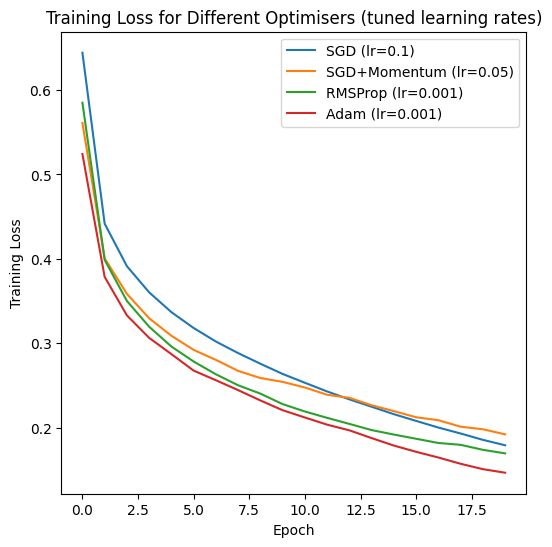

In [46]:
plt.figure(figsize=(6,6))
plt.plot(sgd_tuned_history.history['loss'], label='SGD (lr=0.1)')
plt.plot(sgd_mom_tuned_history.history['loss'], label='SGD+Momentum (lr=0.05)')
plt.plot(rms_tuned_history.history['loss'], label='RMSProp (lr=0.001)')
plt.plot(adam_tuned_history.history['loss'], label='Adam (lr=0.001)')

plt.title("Training Loss for Different Optimisers (tuned learning rates)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

Based on the Results I would choose RMSProp beacuse it reaches validaton accuracy in 3 epochs and further more it has final accuracy of 87% which is best among all even if i see the time it is win win situation

# PART 5

In [56]:
X_train_small = X_train[0:2000]
y_train_small_cat = y_train_cat[0:2000]

print("small training set shape:", X_train_small.shape)

small training set shape: (2000, 784)


In [57]:

overfit_model = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

In [58]:
overfit_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [59]:
overfit_model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
#first i ran 40 to check what is happeining later i change it to 80 
overfit_history = overfit_model.fit(X_train_small, y_train_small_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=80, batch_size=100,
                                     verbose=1)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5945 - loss: 1.1756 - val_accuracy: 0.7275 - val_loss: 0.7233
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7710 - loss: 0.6383 - val_accuracy: 0.7582 - val_loss: 0.6360
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8115 - loss: 0.5050 - val_accuracy: 0.8007 - val_loss: 0.5638
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8400 - loss: 0.4337 - val_accuracy: 0.7995 - val_loss: 0.5694
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8455 - loss: 0.4092 - val_accuracy: 0.8160 - val_loss: 0.5218
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8650 - loss: 0.3794 - val_accuracy: 0.7994 - val_loss: 0.5812
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8825 - loss: 0.3185 - val_accuracy: 0.8048 - val_loss: 0.5954
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8995 - loss: 0.2684 - val_accuracy: 0.8010 - v

In [61]:
final_train_acc = overfit_history.history['accuracy'][-1]
print("final train accuracy:", final_train_acc)

if final_train_acc < 0.99:
    print("train accuracy did not cross 99%, might need more epochs")

final train accuracy: 0.9915000200271606


In [62]:
#differ b/w trainig and validation accuracy
train_loss = overfit_history.history['loss']
val_loss = overfit_history.history['val_loss']

gap = []

for i in range(len(train_loss)):
    gap.append(val_loss[i] - train_loss[i])

separation_epoch = None

for i in range(len(gap)):
    if gap[i] > 0.1:
        separation_epoch = i + 1
        break

print("epoch where start separating:", separation_epoch)

epoch where start separating: 4


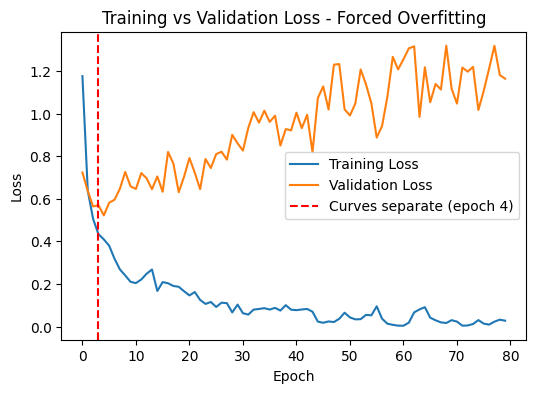

In [63]:
plt.figure(figsize=(6,4))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

if separation_epoch is not None:
    plt.axvline(x=separation_epoch - 1, color='red', linestyle='--',
                label=f'Curves separate (epoch {separation_epoch})')

plt.title("Training vs Validation Loss - Forced Overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [64]:
#generalisation=train accuracy-val accuracy
final_train_acc = overfit_history.history['accuracy'][-1]
final_val_acc = overfit_history.history['val_accuracy'][-1]

gen_gap = final_train_acc - final_val_acc

print("final train accuracy:", final_train_acc)
print("final val accuracy:", final_val_acc)
print("generalisation gap:", gen_gap)

final train accuracy: 0.9915000200271606
final val accuracy: 0.8192499876022339
generalisation gap: 0.17225003242492676


by the numbers it is stated that the model has high variance not hight biasness trainig is at 99% validation stayed at 81% so according to me this is variance also we can see the gap b/w them is 17%